In [103]:
!pip install librosa

In [50]:
#1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [90]:
#2. Load Dataset
files = os.listdir()
print(len(files))
print(files[: 20])
audio_files = []
for file in files:
    if file.endswith('.wav'):
        audio_files.append(file)
print(len(audio_files))
print(audio_files)
print(audio_files[0])

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}
emotion_map["02"]
audio_files[0]



63
['.config', '03-01-08-02-01-01-01.wav', '03-01-05-01-01-01-01.wav', '03-01-08-02-02-01-01.wav', '03-01-02-01-02-02-01.wav', '03-01-06-02-02-02-01.wav', '03-01-04-02-01-01-01.wav', '03-01-07-02-02-01-01.wav', '03-01-03-01-02-01-01.wav', '03-01-07-02-01-02-01.wav', '03-01-07-01-02-01-01.wav', '03-01-05-02-02-01-01.wav', '03-01-03-01-01-01-01.wav', '03-01-06-01-02-02-01.wav', '03-01-03-01-02-02-01.wav', '03-01-08-01-01-02-01.wav', '03-01-08-02-02-02-01.wav', '03-01-04-02-02-02-01.wav', '03-01-04-01-01-02-01.wav', '03-01-06-01-01-02-01.wav']
60
['03-01-08-02-01-01-01.wav', '03-01-05-01-01-01-01.wav', '03-01-08-02-02-01-01.wav', '03-01-02-01-02-02-01.wav', '03-01-06-02-02-02-01.wav', '03-01-04-02-01-01-01.wav', '03-01-07-02-02-01-01.wav', '03-01-03-01-02-01-01.wav', '03-01-07-02-01-02-01.wav', '03-01-07-01-02-01-01.wav', '03-01-05-02-02-01-01.wav', '03-01-03-01-01-01-01.wav', '03-01-06-01-02-02-01.wav', '03-01-03-01-02-02-01.wav', '03-01-08-01-01-02-01.wav', '03-01-08-02-02-02-01.wav', '

'03-01-08-02-01-01-01.wav'

In [91]:
# 4. MFCC Extraction
X = []
Y = []
signals = []
for audio_file in audio_files:
  signal, sr = librosa.load(audio_file)
  signals.append(signal)

  mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

  mfcc_scaled = mfcc.mean(axis = 1)
  mfcc_sd= mfcc.std(axis=1)
  mfcc_features = np.hstack((mfcc_scaled, mfcc_sd))


  parts = audio_file.split("-")
  emotion_code = parts[2]


  emotion_label = emotion_map[emotion_code]
  X.append(mfcc_features)
  Y.append(emotion_label)

print(mfcc_scaled.shape)
print(mfcc_sd.shape)
print(mfcc_features.shape)
print("Number of samples: ",len(X))
print("Number of labels: ",len(Y))

print("First label:", Y[0])
print("Shape of first feature vector:", X[0].shape)

(13,)
(13,)
(26,)
Number of samples:  60
Number of labels:  60
First label: surprised
Shape of first feature vector: (26,)


In [92]:
#5. Dataset Preparation
X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(60, 26)
(60,)


In [93]:
#7. Training
X_train, X_test, Y_train, Y_test = train_test_split (X, Y, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

from sklearn.model_selection import cross_val_score
for n in [10, 50, 100, 200, 500]:
  model = RandomForestClassifier(n_estimators = n, random_state = 42)
  scores = cross_val_score(
    model,
    X,
    Y,
    cv=4
  )
  print(scores)
  print(scores.mean())

  print(
        "Trees:",
        n,
        "Mean Accuracy:",
        scores.mean()
    )
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy: ", accuracy)
print(classification_report(Y_test, Y_pred))
print(set(Y))
from collections import Counter

print(Counter(Y))


(48, 26)
(12, 26)
(48,)
(12,)
[0.53333333 0.46666667 0.4        0.53333333]
0.4833333333333333
Trees: 10 Mean Accuracy: 0.4833333333333333
[0.73333333 0.73333333 0.4        0.73333333]
0.65
Trees: 50 Mean Accuracy: 0.65
[0.8        0.66666667 0.4        0.73333333]
0.65
Trees: 100 Mean Accuracy: 0.65
[0.8        0.73333333 0.46666667 0.73333333]
0.6833333333333333
Trees: 200 Mean Accuracy: 0.6833333333333333
[0.73333333 0.73333333 0.4        0.66666667]
0.6333333333333333
Trees: 500 Mean Accuracy: 0.6333333333333333
Accuracy:  0.5
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         1
        calm       1.00      1.00      1.00         2
     disgust       1.00      0.33      0.50         3
     fearful       0.00      0.00      0.00         1
       happy       0.20      1.00      0.33         1
     neutral       1.00      1.00      1.00         1
         sad       0.33      1.00      0.50         1
   surprised       0.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [94]:
#8. Evaluation
cm = confusion_matrix(Y_test, Y_pred)

print(cm)
print(model.classes_)

[[0 0 0 0 1 0 0 0]
 [0 2 0 0 0 0 0 0]
 [0 0 1 0 2 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 1 0]]
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [95]:
import joblib
joblib.dump(model, "emotion_model.pkl")


['emotion_model.pkl']

In [96]:
os.listdir()

['.config',
 '03-01-08-02-01-01-01.wav',
 '03-01-05-01-01-01-01.wav',
 '03-01-08-02-02-01-01.wav',
 '03-01-02-01-02-02-01.wav',
 '03-01-06-02-02-02-01.wav',
 '03-01-04-02-01-01-01.wav',
 '03-01-07-02-02-01-01.wav',
 '03-01-03-01-02-01-01.wav',
 '03-01-07-02-01-02-01.wav',
 '03-01-07-01-02-01-01.wav',
 '03-01-05-02-02-01-01.wav',
 '03-01-03-01-01-01-01.wav',
 '03-01-06-01-02-02-01.wav',
 '03-01-03-01-02-02-01.wav',
 '03-01-08-01-01-02-01.wav',
 '03-01-08-02-02-02-01.wav',
 '03-01-04-02-02-02-01.wav',
 '03-01-04-01-01-02-01.wav',
 '03-01-06-01-01-02-01.wav',
 '03-01-04-01-02-01-01.wav',
 '03-01-03-01-01-02-01.wav',
 '03-01-07-01-02-02-01.wav',
 '03-01-04-02-02-01-01.wav',
 '03-01-01-01-01-02-01.wav',
 '03-01-02-02-01-02-01.wav',
 '03-01-06-02-01-01-01.wav',
 '03-01-02-02-02-01-01.wav',
 '03-01-06-01-02-01-01.wav',
 '03-01-06-01-01-01-01.wav',
 '03-01-07-02-01-01-01.wav',
 '03-01-05-02-01-02-01.wav',
 '03-01-08-01-02-02-01.wav',
 '03-01-02-02-01-01-01.wav',
 '03-01-07-01-01-01-01.wav',
 '

In [97]:
loaded_model = joblib.load("emotion_model.pkl")
print(loaded_model)

RandomForestClassifier(n_estimators=500, random_state=42)


In [98]:

def predict_emotion(audio_file):
  test_audio = audio_file
  signal, sr = librosa.load(test_audio)
  mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
  mfcc_scaled = mfcc.mean(axis = 1)
  mfcc_sd= mfcc.std(axis=1)
  features = np.hstack((mfcc_scaled, mfcc_sd))

  features = features.reshape(1, -1)
  print(features.shape)
  prediction = loaded_model.predict(features)
  print(prediction)

  parts = test_audio.split("-")
  actual = emotion_map[parts[2]]
  print(actual)
  print("Actual:", actual)
  print("Predicted:", prediction[0])
  return prediction[0]



In [99]:
predict_emotion(audio_files[0])
os.path.exists(audio_files[0])

(1, 26)
['happy']
surprised
Actual: surprised
Predicted: happy


True

In [100]:
for i in range(5):
    print(audio_files[i])
    predict_emotion(audio_files[i])
    print("-"*40)

03-01-08-02-01-01-01.wav
(1, 26)
['happy']
surprised
Actual: surprised
Predicted: happy
----------------------------------------
03-01-05-01-01-01-01.wav
(1, 26)
['angry']
angry
Actual: angry
Predicted: angry
----------------------------------------
03-01-08-02-02-01-01.wav
(1, 26)
['surprised']
surprised
Actual: surprised
Predicted: surprised
----------------------------------------
03-01-02-01-02-02-01.wav
(1, 26)
['calm']
calm
Actual: calm
Predicted: calm
----------------------------------------
03-01-06-02-02-02-01.wav
(1, 26)
['fearful']
fearful
Actual: fearful
Predicted: fearful
----------------------------------------


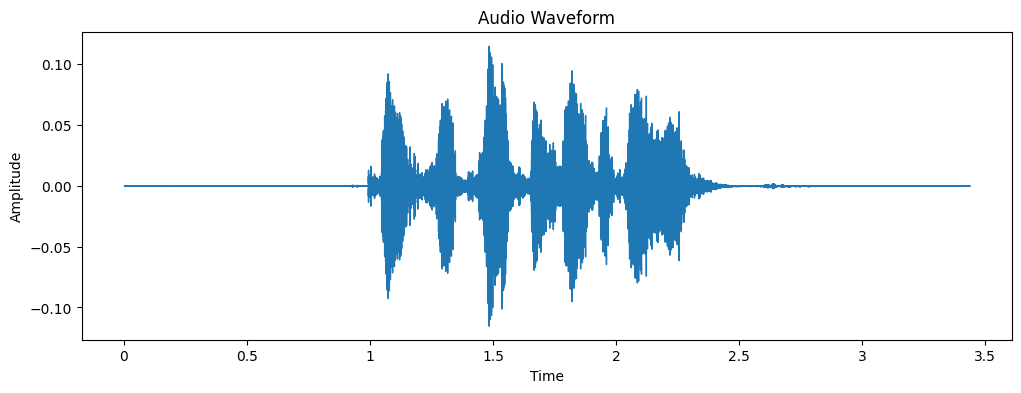

In [101]:
signal, sr = librosa.load(audio_files[0])

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    signal,
    sr=sr
)

plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

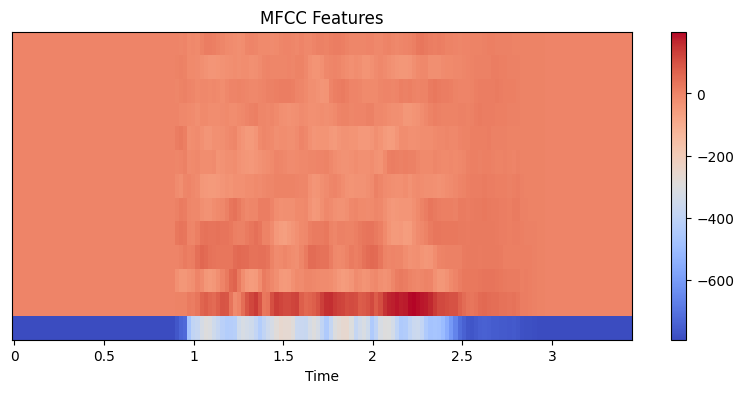

In [102]:
signal, sr = librosa.load(audio_files[0])

mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()